In [1]:
import os
import skillsnetwork

data_dir = "."
dataset_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/4Z1fwRR295-1O3PMQBH6Dg/images-dataSAT.tar"


def check_skillnetwork_extraction(extract_dir):
    """Check if the environment allows symlink creation for download/extraction."""
    symlink_test = os.path.join(extract_dir, "symlink_test")
    if not os.path.exists(symlink_test):
        os.symlink(os.path.join(os.sep, "tmp"), symlink_test)
        print("Write permissions available for downloading and extracting the dataset tar file")
        os.unlink(symlink_test)

async def download_tar_dataset(url, tar_path, extract_dir):
    """Download and extract dataset tar file asynchronously."""
    if not os.path.exists(tar_path):
        try:
            print(f"Downloading from {url}...")
            import httpx
            async with httpx.AsyncClient() as client:
                response = await client.get(url, follow_redirects=True)
                response.raise_for_status()
                with open(tar_path, "wb") as f:
                    f.write(response.content)
            print(f"Successfully downloaded '{tar_path}'.")
        except Exception as e:
            print(f"Download error: {e}")
    else:
        print(f"Dataset tar file already exists at: {tar_path}")
    import tarfile
    with tarfile.open(tar_path, 'r:*') as tar_ref:
        tar_ref.extractall(path=extract_dir)
        print(f"Successfully extracted to '{extract_dir}'.")

try:
    check_skillnetwork_extraction(data_dir)
    await skillsnetwork.prepare(url=dataset_url, path=data_dir, overwrite=True)
except Exception as e:
    print(e)
    print("Primary download/extraction method failed.")
    print("Falling back to manual download and extraction...")
    import tarfile
    import httpx
    from pathlib import Path
    file_name = Path(dataset_url).name
    tar_path = os.path.join(data_dir, file_name)
    await download_tar_dataset(dataset_url, tar_path, data_dir)

Write permissions available for downloading and extracting the dataset tar file


  0%|          | 0/6003 [00:00<?, ?it/s]

Saved to '.'


In [2]:
%%time
%%capture captured_output
%pip install numpy==1.26
%pip install matplotlib==3.9.2
%pip install skillsnetwork

CPU times: user 4.19 ms, sys: 10.2 ms, total: 14.4 ms
Wall time: 1.09 s


In [3]:
%%time
%pip install torch==2.7.0

Note: you may need to restart the kernel to use updated packages.
CPU times: user 1.79 ms, sys: 4.04 ms, total: 5.83 ms
Wall time: 316 ms


In [4]:
%%time
%pip install torchvision==0.22

Note: you may need to restart the kernel to use updated packages.
CPU times: user 2.3 ms, sys: 3.82 ms, total: 6.12 ms
Wall time: 332 ms


In [5]:
%%time
%pip install tensorflow==2.19

ERROR: Could not find a version that satisfies the requirement tensorflow==2.19 (from versions: 2.20.0rc0, 2.20.0, 2.21.0rc0)
ERROR: No matching distribution found for tensorflow==2.19
Note: you may need to restart the kernel to use updated packages.
CPU times: user 2.28 ms, sys: 4.06 ms, total: 6.34 ms
Wall time: 362 ms


In [6]:
%%time
%pip install scikit-learn==1.7.0

Note: you may need to restart the kernel to use updated packages.
CPU times: user 1.73 ms, sys: 4.15 ms, total: 5.88 ms
Wall time: 309 ms


In [7]:
%%time
import warnings
warnings.filterwarnings('ignore')

import os
import time
import httpx
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

CPU times: user 5.5 ms, sys: 2.85 ms, total: 8.35 ms
Wall time: 11.8 ms


In [8]:
%%time
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import torch.nn.functional as F

print("Imported libraries")

Imported libraries
CPU times: user 697 ms, sys: 144 ms, total: 842 ms
Wall time: 1.13 s


In [9]:
%%time
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.initializers import HeUniform
from tensorflow.keras.callbacks import ModelCheckpoint

gpu_list = tf.config.list_physical_devices('GPU')
device = "gpu" if gpu_list != [] else "cpu"
print(f"Device available for training: {device}")

Device available for training: cpu
CPU times: user 1.72 s, sys: 288 ms, total: 2.01 s
Wall time: 2.59 s


In [10]:
%%time
from sklearn.metrics import (accuracy_score,
                             precision_score,
                             recall_score,
                             f1_score,
                             roc_curve, 
                             roc_auc_score,
                             log_loss,
                             classification_report,
                             confusion_matrix,
                             ConfusionMatrixDisplay,
                            )
from sklearn.preprocessing import label_binarize

# define a function to get the metrics comprehensively
def model_metrics(y_true, y_pred, y_prob, class_labels):
    metrics = {'Accuracy': accuracy_score(y_true, y_pred),
               'Precision': precision_score(y_true, y_pred),
               'Recall': recall_score(y_true, y_pred),
               'Loss': log_loss(y_true, y_prob),
               'F1 Score': f1_score(y_true, y_pred),
               'ROC-AUC': roc_auc_score(y_true, y_prob),
               'Confusion Matrix': confusion_matrix(y_true, y_pred),
               'Classification Report': classification_report(y_true, y_pred, target_names=class_labels, digits=4),
               "Class labels": class_labels
              }
    return metrics

#function to print the metrics
def print_metrics(y_true, y_pred, y_prob, class_labels, model_name):
    metrics = model_metrics(y_true, y_pred, y_prob, class_labels)
    print(f"Evaluation metrics for the \033[1m{model_name}\033[0m")
    print(f"Accuracy: {'':<1}{metrics["Accuracy"]:.4f}")
    print(f"ROC-AUC: {'':<2}{metrics["ROC-AUC"]:.4f}")
    print(f"Loss: {'':<5}{metrics["Loss"]:.4f}\n")
    print(f"Classification report:\n\n  {metrics["Classification Report"]}")
    print("========= Confusion Matrix =========")
    disp = ConfusionMatrixDisplay(confusion_matrix=metrics["Confusion Matrix"],
                                  display_labels=metrics["Class labels"])

    disp.plot()
    plt.show()



CPU times: user 79.8 ms, sys: 12.3 ms, total: 92.1 ms
Wall time: 97.5 ms


In [11]:
async def download_model(url, model_path):
    if not os.path.exists(model_path):
        try:
            print(f"Downloading from {url}...")
            import httpx
            async with httpx.AsyncClient() as client:
                response = await client.get(url, follow_redirects=True)
                response.raise_for_status()
                with open(model_path, "wb") as f:
                    f.write(response.content)
            print(f"Successfully downloaded '{model_path}'.")
        except Exception as e:
            print(f"Download error: {e}")
    else:
        print(f"Model file already downloaded at: {model_path}")

In [12]:
data_dir = "."

keras_model_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/U-uPeyCyOQYh0GrZPGsqoQ/ai-capstone-keras-best-model-model.keras"
keras_model_name = "ai-capstone-keras-best-model-model_downloaded.keras"
keras_model_path = os.path.join(data_dir, keras_model_name)

pytorch_state_dict_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/8J2QEyQqD8x9zjrlnv6N7g/ai-capstone-pytorch-best-model-20250713.pth"
pytorch_state_dict_name = "ai_capstone_pytorch_best_model_state_dict_downloaded.pth"
pytorch_state_dict_path = os.path.join(data_dir, pytorch_state_dict_name)

await download_model(keras_model_url, keras_model_path)
await download_model(pytorch_state_dict_url, pytorch_state_dict_path)

Model file already downloaded at: ./ai-capstone-keras-best-model-model_downloaded.keras
Model file already downloaded at: ./ai_capstone_pytorch_best_model_state_dict_downloaded.pth


In [13]:
dataset_path = os.path.join(data_dir, "images_dataSAT")
print(dataset_path)

img_w, img_h = 64, 64
n_channels = 3
batch_size = 128
num_classes = 2

agri_class_labels = ["non-agri", "agri"]


./images_dataSAT


In [14]:
%%time

datagen = ImageDataGenerator(rescale=1./255)
prediction_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(img_w, img_h),
    batch_size=batch_size,
    class_mode="binary",
    shuffle=False
)

keras_model = tf.keras.models.load_model(keras_model_path)

steps = int(np.ceil(prediction_generator.samples / prediction_generator.batch_size))
batch_size = int(prediction_generator.batch_size)
print(f"Number of Steps: {steps} with batch size: {batch_size}")

all_preds_keras = []
all_probs_keras = []
all_labels_keras = []

for step_idx, step in enumerate(tqdm(range(steps), desc="Steps")):
    images, labels = next(prediction_generator)
    preds = keras_model.predict(images, verbose='0')
    all_probs_keras.extend(preds)
    preds = (preds > 0.5).astype(int).flatten()
    all_preds_keras.extend(preds)
    all_labels_keras.extend(labels)

Found 6000 images belonging to 2 classes.
Number of Steps: 47 with batch size: 128


Steps: 100%|██████████| 47/47 [00:09<00:00,  4.71it/s]

CPU times: user 1min 6s, sys: 3.01 s, total: 1min 9s
Wall time: 10.4 s


In [15]:
print("What preds > 0.5 does:")
print("It converts all predictions greater than 0.5 to True, assigning them to class 1 (agri).")
print("Predictions ≤ 0.5 are converted to False, assigned to class 0 (non-agri).")
print("This is a threshold operation converting continuous sigmoid probability outputs")
print("into discrete binary class predictions.")
print(".astype(int) converts the boolean array to integers 0 or 1.")
print(".flatten() reshapes from 2D to 1D array for comparison with true labels.")
print()
print("Example:")
print("probability 0.8 → 0.8 > 0.5 → True → 1 (agri)")
print("probability 0.3 → 0.3 > 0.5 → False → 0 (non-agri)")


What preds > 0.5 does:
It converts all predictions greater than 0.5 to True, assigning them to class 1 (agri).
Predictions ≤ 0.5 are converted to False, assigned to class 0 (non-agri).
This is a threshold operation converting continuous sigmoid probability outputs
into discrete binary class predictions.
.astype(int) converts the boolean array to integers 0 or 1.
.flatten() reshapes from 2D to 1D array for comparison with true labels.

Example:
probability 0.8 → 0.8 > 0.5 → True → 1 (agri)
probability 0.3 → 0.3 > 0.5 → False → 0 (non-agri)


Task 1: Printing performance metrics for the Keras model using print_metrics function
----------------------------------------------------------------------
Evaluation metrics for the Keras Model
Accuracy:  0.9917
ROC-AUC:   1.0000
Loss:      0.0257

Classification report:

                precision    recall  f1-score   support

    non-agri     0.9836    1.0000    0.9917      3000
        agri     1.0000    0.9833    0.9916      3000

    accuracy                         0.9917      6000
   macro avg     0.9918    0.9917    0.9917      6000
weighted avg     0.9918    0.9917    0.9917      6000

========= Confusion Matrix =========


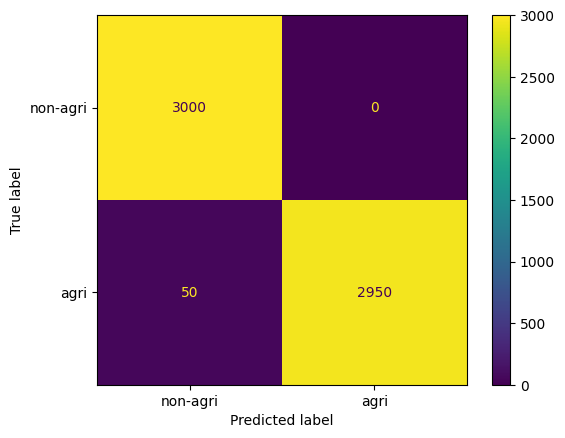

In [16]:
## Please use the space below to write your answer
# Task 1: Print performance metrics for the Keras model using print_metrics function
print("Task 1: Printing performance metrics for the Keras model using print_metrics function")
print("-" * 70)
print_metrics(
    y_true=all_labels_keras,
    y_pred=all_preds_keras,
    y_prob=all_probs_keras,
    class_labels=agri_class_labels,
    model_name="Keras Model"
)



In [17]:
%%time
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Processing inference on {device}")

train_transform = transforms.Compose([
    transforms.Resize((img_w, img_h)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
full_dataset = datasets.ImageFolder(dataset_path, transform=train_transform)
test_loader = DataLoader(full_dataset, batch_size=batch_size, shuffle=False)

model = nn.Sequential(
    nn.Conv2d(3, 32, 5, padding=2), nn.ReLU(),
    nn.MaxPool2d(2), nn.BatchNorm2d(32),
    nn.Conv2d(32, 64, 5, padding=2), nn.ReLU(), nn.MaxPool2d(2), nn.BatchNorm2d(64),
    nn.Conv2d(64, 128, 5, padding=2), nn.ReLU(), nn.MaxPool2d(2), nn.BatchNorm2d(128),
    nn.Conv2d(128, 256, 5, padding=2), nn.ReLU(), nn.MaxPool2d(2), nn.BatchNorm2d(256),
    nn.Conv2d(256, 512, 5, padding=2), nn.ReLU(), nn.MaxPool2d(2), nn.BatchNorm2d(512),
    nn.Conv2d(512, 1024, 5, padding=2), nn.ReLU(), nn.MaxPool2d(2), nn.BatchNorm2d(1024),
    nn.AdaptiveAvgPool2d(1), nn.Flatten(),
    nn.Linear(1024, 2048), nn.ReLU(), nn.BatchNorm1d(2048), nn.Dropout(0.4),
    nn.Linear(2048, num_classes)
).to(device)

print("Created model, now loading the weights from saved model state dict")
model.load_state_dict(torch.load(pytorch_state_dict_path))
print("Loaded model state dict, now getting predictions")

all_preds_pytorch = []
all_labels_pytorch = []
all_probs_pytorch = []


model.eval()
with torch.no_grad():
    for batch_idx, (images, labels) in enumerate(tqdm(test_loader, desc="Step")):
#    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        probs = F.softmax(outputs, dim=1)[:, 1]  # probability for class 1
        all_probs_pytorch.extend(probs.cpu())
        all_preds_pytorch.extend(preds.cpu().numpy().flatten())
        all_labels_pytorch.extend(labels.numpy())

Processing inference on cpu
Created model, now loading the weights from saved model state dict
Loaded model state dict, now getting predictions


Step: 100%|██████████| 47/47 [00:12<00:00,  3.67it/s]

CPU times: user 42.8 s, sys: 2.65 s, total: 45.4 s
Wall time: 12.9 s


Evaluation metrics for the PyTorch Model
Accuracy:  0.9988
ROC-AUC:   1.0000
Loss:      0.0023

Classification report:

                precision    recall  f1-score   support

    non-agri     0.9993    0.9983    0.9988      3000
        agri     0.9983    0.9993    0.9988      3000

    accuracy                         0.9988      6000
   macro avg     0.9988    0.9988    0.9988      6000
weighted avg     0.9988    0.9988    0.9988      6000

========= Confusion Matrix =========


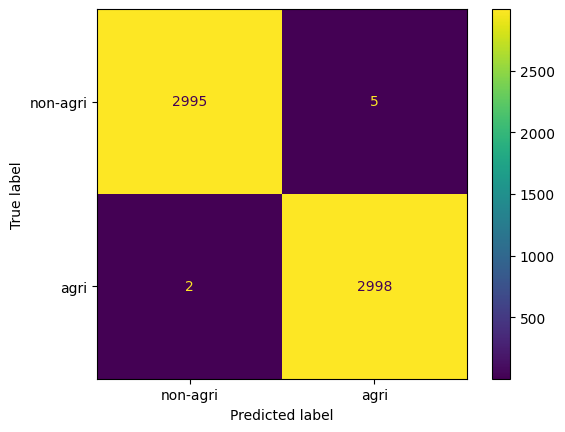

In [18]:
## Please use the space below to write your answer
print_metrics(
    y_true=all_labels_pytorch,
    y_pred=all_preds_pytorch,
    y_prob=all_probs_pytorch,
    class_labels=agri_class_labels,
    model_name="PyTorch Model"
)



In [19]:
# Answer: Total number of false negatives in the PyTorch confusion matrix
# Compute confusion matrix for verification
from sklearn.metrics import confusion_matrix
cm_pytorch = confusion_matrix(all_labels_pytorch, all_preds_pytorch)

print("Confusion Matrix for PyTorch Model:")
print("           non-agri    agri")
print("non-agri    ", cm_pytorch[0,0], "      ", cm_pytorch[0,1])
print("agri        ", cm_pytorch[1,0], "      ", cm_pytorch[1,1])
print()
print("Confusion Matrix values:")
print("True Negatives (non-agri → non-agri):", cm_pytorch[0,0])
print("False Negatives (non-agri → agri):  ", cm_pytorch[0,1])
print("False Positives (agri → non-agri):  ", cm_pytorch[1,0])
print("True Positives (agri → agri):       ", cm_pytorch[1,1])
print()
print("Total False Negatives in the confusion matrix:", cm_pytorch[0,1])



Confusion Matrix for PyTorch Model:
           non-agri    agri
non-agri     2995        5
agri         2        2998

Confusion Matrix values:
True Negatives (non-agri → non-agri): 2995
False Negatives (non-agri → agri):   5
False Positives (agri → non-agri):   2
True Positives (agri → agri):        2998

Total False Negatives in the confusion matrix: 5


In [20]:

def plot_roc(y_true, y_prob, model_name):
    n_classes = y_prob.shape[1] if y_prob.ndim > 1 else 1
    if n_classes == 1:
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        auc = roc_auc_score(y_true, y_prob)
        plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.2f})')
    else:
        y_true_bin = label_binarize(y_true, classes=np.arange(n_classes))
        for i in range(n_classes):
            fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
            auc = roc_auc_score(y_true_bin[:, i], y_prob[:, i])
            plt.plot(fpr, tpr, label=f'{model_name} class {i} (AUC = {auc:.2f})')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()

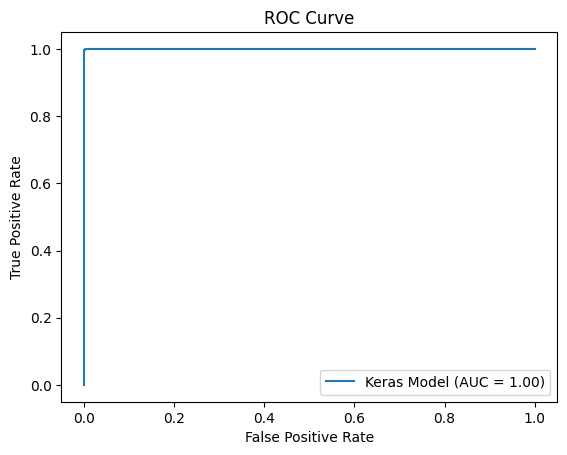

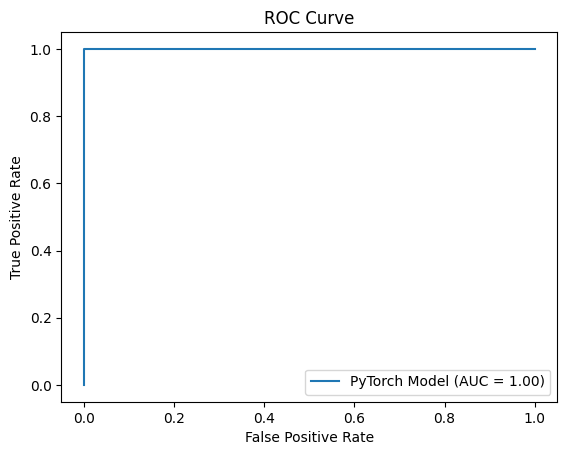

In [21]:
plot_roc(np.array(all_labels_keras), np.array(all_probs_keras), "Keras Model")
plt.show()
plot_roc(np.array(all_labels_pytorch), np.array(all_probs_pytorch), "PyTorch Model")
plt.show()

In [22]:
# get the Keras model performance metrics
metrics_keras = model_metrics(all_labels_keras, all_preds_keras, all_probs_keras, agri_class_labels)

# get the PyTorch model performance metrics
metrics_pytorch = model_metrics(all_labels_pytorch, all_preds_pytorch, all_probs_pytorch, agri_class_labels)


# Display the comparison of metrics
print("{:<18} {:<15} {:<15}".format('\033[1m'+ 'Metric' + '\033[0m',
                                    'Keras Model', 
                                    'PyTorch Model'))

mertics_list = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']

for k in mertics_list:
    print("{:<18} {:<15.4f} {:<15.4f}".format('\033[1m'+k+'\033[0m',
                                              metrics_keras[k],
                                              metrics_pytorch[k]))

Metric     Keras Model     PyTorch Model  
Accuracy   0.9917          0.9988         
Precision  1.0000          0.9983         
Recall     0.9833          0.9993         
F1 Score   0.9916          0.9988         
ROC-AUC    1.0000          1.0000         
